# Training and Fine-Tuning BERT for Classification
## Classfying Goodreads Reviews By Book Genre

By Maria Antoniak, Melanie Walsh, and the [AI for Humanists](https://aiforhumanists.com/) Team

Updated: 2024-11-05
<br></br>

This notebook will demonstrate how users can train and fine-tune a BERT model for classification with the popular HuggingFace `transformers` Python library.

We will fine-tune a BERT model on Goodreads reviews from the [UCSD Book Graph](https://mengtingwan.github.io/data/goodreads.html) with the goal of predicting the genre of the book being reviewed. The genres include:
- poetry
- comics & graphic
- fantasy & paranormal
- history & biography
- mystery, thriller, & crime
- romance
- young adult  

**Basic steps involved in using BERT and HuggingFace:**
1. Divide your data into training and test sets.
2. Encode your data into a format BERT will understand.
3. Combine your data and labels into datset objects.
4. Load the pre-trained BERT model.
5. Fine-tune the model using your training data.
6. Predict new labels and evaluate performance on your test data.



<br><br>

## **Import necessary Python libraries and modules**

First, we will import necessary Python libraries and modules. These include as `gdown`, for downloading large files from Google Drive (where we will get our UCSD Goodreads reviews), as well as scikit-learn (`sklearn`) and PyTorch (`torch`), for various machine learning tools.

In [1]:
!pip3 install -U transformers

   ━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/10.8 MB 96.9 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 6.3/10.8 MB 93.7 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸ 10.8/10.8 MB 89.6 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 60.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/668.2 kB ? eta -:--:--

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.2/668.2 kB 35.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/4.5 MB ? eta -:--:--

...

      Successfully uninstalled huggingface_hub-1.4.1


  Attempting uninstall: transformers


    Found existing installation: transformers 5.0.0


    Uninstalling transformers-5.0.0:


      Successfully uninstalled transformers-5.0.0


In [2]:
# Basic Python modules
from collections import defaultdict
import random
import pickle

# For downloading large files from Google Drive
# https://github.com/wkentaro/gdown
import gdown

# For working with gzip files
# https://docs.python.org/3/library/gzip.html
import gzip

# For working with JSON files
import json

# For data manipulation and analysis
import pandas as pd
import numpy as np

# For machine learning tools and evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# For deep learning
# https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
import torch

# For plotting and data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

The HuggingFace [`transformers` Python library](https://huggingface.co/transformers/installation.html) is included in Colab by default now, so we do not need to install it (but this is how you would install it with `pip`).

From `transformers`, we will import modules for `DistilBert`, a *distilled* or smaller version of a BERT model that runs more quickly and uses less computing power. This makes it ideal for those just getting started with BERT.

# **Training the Model on Kaggle & Tracking with W&B**

In [3]:
!pip install wandb==0.25.0

In [4]:
# Setting up Kaggle secrets
from kaggle_secrets import UserSecretsClient

secrets = UserSecretsClient()
WANDB_API_KEY = secrets.get_secret('WANDB_API_KEY')
HF_TOKEN = secrets.get_secret('HF_TOKEN')

import os
os.environ['WANDB_API_KEY'] = WANDB_API_KEY
os.environ['HF_TOKEN'] = HF_TOKEN


In [5]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

<br><br>

## **Set parameters and file paths**

In [6]:
# This is the name of the BERT model that we want to use.
# We're using DistilBERT to save space (it's a distilled version of the full BERT model),
# and we're going to use the cased (vs uncased) version.
model_name = 'distilbert-base-cased'

# This is the name of the program management system for NVIDIA GPUs. We're going to send our code here.
device_name = 'cuda'

# This is the maximum number of tokens in any document sent to BERT.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = 'distilbert-reviews-genres'

<br><br>

## **Load and sample Goodreads data**

In this cell, we create a Python dictionary with each genre and the link to the corresponding UCSD Goodreads review data for that genre.

*If you manually click on any of the URLs, you will be able to download the data for that genre. For example, here's the link for poetry: https://datarepo.eng.ucsd.edu/mcauley_group/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz*

# **Task: Preparing and Encoding the Dataset**

In [7]:
# This is where our target data is hosted on the web. You only need these paths for the book review dataset.

# Source: https://mengtingwan.github.io/data/goodreads.html#datasets

genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

Next we loop through this dictionary and use `gdown` to download the Goodreads review data for each genre from Google Drive.

Now we will load the first 100,000 reviews from each link and randomly sample 2,000 reviews.

In [8]:
import requests
# Stream reviews from URL and collect a subset
def load_reviews(url, head=10000, sample_size=2000):
    reviews = []
    count = 0

    response = requests.get(url, stream=True)
    print(response)
    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            d = json.loads(line)
            reviews.append(d['review_text'])
            count += 1

            # Stop if we have reached the 100,000 limit
            if head is not None and count >= head:
                break

    # Return random sample of reviews
    return random.sample(reviews, min(sample_size, len(reviews)))

# Reviews by genre
genre_reviews_dict = {}

# Load reviews for each genre
for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=10000, sample_size=2000)


Loading reviews for genre: poetry


<Response [200]>


Loading reviews for genre: children


<Response [200]>


Loading reviews for genre: comics_graphic


...

<Response [200]>


Loading reviews for genre: romance


<Response [200]>


Loading reviews for genre: young_adult


<Response [200]>


Let's preview a couple of the key-value pairs in `genre_reviews_dict`

In [9]:
 for _genre, _reviews in genre_reviews_dict.items():
    print(_genre)
    print(random.sample(_reviews, 1)[0])

poetry
I listened to this on Audible in an attempt to a) read more; b) learn how to use Audible for my class; and c) give audiobooks a chance. I thought poetry would be better than other stuff in audiobook form; I cannot escape the feeling of cheesiness with audiobooks. And poetry probably is better in audiobook form, but what I discovered here is that I'd rather read Pablo Neruda in Spanish, and to do that, I need to read, not listen, because that's just where I am with Spanish. 
 This collection itself is compiled really well, at least for my taste. It's mostly "odes" - as in, "ode" is in the title of most of the poems - to everyday objects and the common person. Several fruits and animals are featured, for example. I was listening to this particular collection of Neruda poems particularly to fulfill the Read Harder Challenge's "a collection of poetry in translation on a theme other than love," and while this book is definitely not a collection of romantic love poems, I also hesitate

Here we use `pickle` to save this Python dictionary to a `.pickle` file so we can easily load it later.

*The `pickle` module allows you to save and load Python objects like lists and dictionaries.*

In [10]:
pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))
# genre_reviews_dict = pickle.load(open('genre_reviews_dict.pickle', 'rb'))

<br><br>

## **Split the data into training and test sets**

When training a machine learning model, it is necessary to split your training data into two parts: a "training" set and a "test" set.

We will train our BERT model on the "training" set of Goodreads reviews and then we will evaluate how well it is performing by running it on the "test" set of Goodreads reviews that the model has never seen before.

Normally, to tune the hyperparameters, you should also create a "validation" set for tuning, and only use the "test" set once, at the end of all tuning. For simplicity, in this tutorial, we will only using a training and test set.

In [11]:
train_texts = []
train_labels = []

test_texts = []
test_labels = []

for _genre, _reviews in genre_reviews_dict.items():

  _reviews = random.sample(_reviews, 1000) # Use a very small set as an example.

  for _review in _reviews[:800]:
    train_texts.append(_review)
    train_labels.append(_genre)
  for _review in _reviews[800:]:
    test_texts.append(_review)
    test_labels.append(_genre)

Show how many Goodreads reviews and labels we have in each category: 6400 training reviews, 6400 training labels (genres), 1600 test reviews, 1600 test labels (genre)

In [12]:
len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(6400, 6400, 1600, 1600)

Here's an example of a training label and review:

In [13]:
train_labels[0], train_texts[0]

('poetry',
 "Wow. This book is AMAZING. Little did I know what I was getting into when I started reading it. It is quite existential, which at points might be a little pessimistic for some. But, I can't say enough about how beautiful Pessoa's words are. It truly spoke to me. It is just one of those books... and I think many people would get so much out of reading it. I am still flipping through it to certain passages that I've marked. It will definitely be one of those books that I re-visit many times.")

<br><br>

## **Run a baseline model (logistic regression)**

Here we train and evaluate a simple TF-IDF baseline model using logistic regression.

We find better-than-random performance, even for a very small dataset. We'll see whether BERT can beat this good baseline!

In [14]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

We train a logistic regression model from scikit-learn on the Goodreads training data, and then we use the trained model to make predictions on our Goodreads review test set.

In [15]:
model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
predictions = model.predict(X_test)

We can use scikit-learn's `classification_report` function to evaluate how well the logistic regression model's predictions match up with the true labels for the Goodreads reviews.

Importantly, we can see that our average scores are above random performance (we have 8 classes, so random performance would be ~0.2).

In [16]:
print(classification_report(test_labels, predictions))

                        precision    recall  f1-score   support

              children       0.58      0.61      0.60       200
        comics_graphic       0.78      0.67      0.72       200
    fantasy_paranormal       0.33      0.29      0.31       200
     history_biography       0.53      0.51      0.52       200
mystery_thriller_crime       0.53      0.55      0.54       200
                poetry       0.63      0.75      0.69       200
               romance       0.60      0.67      0.64       200
           young_adult       0.37      0.34      0.35       200

              accuracy                           0.55      1600
             macro avg       0.55      0.55      0.55      1600
          weighted avg       0.55      0.55      0.55      1600



<br><br>

## **Encode data for BERT**

We're going to transform our texts and labels into a format that BERT (via Huggingface and PyTorch) will understand. This is called *encoding* the data.

Here are the steps we need to follow:

1. The labels&mdash;in this case, Goodreads genres&mdash;need to be turned into integers rather than strings.

2. The texts&mdash;in this case, Goodreads reviews&mdash;need to be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens. The tokens, or words in the texts, also need to be separated into "word pieces" and matched to their embedding vectors.

3. We need to add special tokens to help BERT:

| BERT special token | Explanation |
| --------------| ---------|
| [CLS] | Start token of every document. |
| [SEP] | Separator between each sentence |
| [PAD] | Padding at the end of the document as many times as necessary, up to 512 tokens |
|  &#35;&#35; | Start of a "word piece" |




Here we will load `DistilBertTokenizerFast` from the HuggingFace library, which will do all the work of encoding the texts for us. The `tokenizer()` will break word tokens into word pieces, truncate to 512 tokens, and add padding and special BERT tokens.

# **Task: Load Tokenizer**

**Loading DistilBertTokenizerFast from Hugging face to tokenize book reviews. The tokenizer convers raw text into token IDs that the model can process.**

In [17]:
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name) # The model_name needs to match our pre-trained model.

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Here we will create a map of our labels, or Goodreads genres, to integer keys. We take the unique labels, and then we make a dictionary that associates each label/tag with an integer.

**Note:** HuggingFace documentation sometimes refers to "labels" as "tags" but these are the same thing. We use "labels" throughout this notebook for clarity.

In [18]:
unique_labels = set(label for label in train_labels)
label2id = {label: id for id, label in enumerate(unique_labels)}
id2label = {id: label for label, id in label2id.items()}

In [19]:
label2id.keys()

dict_keys(['comics_graphic', 'poetry', 'romance', 'young_adult', 'fantasy_paranormal', 'history_biography', 'mystery_thriller_crime', 'children'])

In [20]:
id2label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

Now let's encode our texts and labels!

In [21]:
train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

**Examine a Goodreads review in the training set after encoding**

In [22]:
' '.join(train_encodings[0].tokens[0:100])

"[CLS] Wow . This book is AM ##A ##Z ##ING . Little did I know what I was getting into when I started reading it . It is quite exist ##ential , which at points might be a little p ##ess ##im ##istic for some . But , I can ' t say enough about how beautiful P ##ess ##oa ' s words are . It truly spoke to me . It is just one of those books . . . and I think many people would get so much out of reading it . I am still flipping through"

**Examine a Goodreads review in the test set after encoding**

In [23]:
' '.join(test_encodings[0].tokens[0:100])

"[CLS] 52 was a project that changed lives . You probably haven ' t heard of most of the poets in the book . You might have heard of some of them . You will definitely be hearing more of them . I didn ' t love all the poems but I didn ' t expect to - it ' s an anthology . But I did like most of them - and there were some that I absolutely loved ( Mary Gil ##on ##ne ' s Paper ##maker for example ) . The quality of the poems is consistently"

**Examine the training labels after encoding**

In [24]:
set(train_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

**Examine the test labels after encoding**

In [25]:
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

<br><br>

## **Make a custom Torch dataset**

Here we combine the encoded labels and texts into dataset objects. We use the custom Torch `MyDataSet` class to make a `train_dataset` object from  the `train_encodings` and `train_labels_encoded`. We also make a `test_dataset` object from `test_encodings`, and `test_labels_encoded`.

In [26]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [27]:
train_dataset = MyDataset(train_encodings, train_labels_encoded)
test_dataset = MyDataset(test_encodings, test_labels_encoded)

**Examine a Goodreads review in the Torch `training_dataset` after encoding**

In [28]:
' '.join(train_dataset.encodings[0].tokens[0:100])

"[CLS] Wow . This book is AM ##A ##Z ##ING . Little did I know what I was getting into when I started reading it . It is quite exist ##ential , which at points might be a little p ##ess ##im ##istic for some . But , I can ' t say enough about how beautiful P ##ess ##oa ' s words are . It truly spoke to me . It is just one of those books . . . and I think many people would get so much out of reading it . I am still flipping through"

**Examine a Goodreads review in the Torch `test_dataset` after encoding**

In [29]:
' '.join(test_dataset.encodings[1].tokens[0:100])

'[CLS] Sony ##a Son ##es has a great gift for creating novels in verse that read like someone whispering truth in your ear . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

<br><br>

## **Load pre-trained BERT model**

Here we load a pre-trained DistilBERT model and send it to CUDA.

**Note:** If you decide to repeat fine-tuning after already running the following cells, make sure that you re-run this cell to re-load the original pre-trained model before fine-tuning again.

# **Task: Load a Pretained Model from Hugging Face.**

In [30]:
# The model_name needs to match the name used for the tokenizer above.
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=len(id2label)).to(device_name)

config.json:   0%|          | 0.00/465 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/263M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


<br><br>

## **Set the BERT fine-tuning parameters**

These are the arguments we'll set in the HuggingFace TrainingArguments objects, which we'll then pass to the HuggingFace Trainer object. There are many more possible arguments, but here we highlight the basics and some common gotchas.

When training your own model, you should search over these parameters to find the best settings for your particular dataset. You should use a held-out set of validation data for this step.

| Parameter | Explanation |
|-----------| ------------|
| num_train_epochs | total number of training epochs (how many times to pass through the entire dataset; too much can cause overfitting) |
| per_device_train_batch_size | batch size per device during training |
| per_device_eval_batch_size |  batch size for evaluation |
|  warmup_steps |  number of warmup steps for learning rate scheduler (set lower because of small dataset size) |
| weight_decay | strength of weight decay (reduces size of weights, like regularization) |
| output_dir | output directory for the fine-tuned model and configuration files |
| logging_dir | directory for storing logs |
| logging_steps | how often to print logging output (so that we can stop training early if the loss isn't going down) |
| evaluation_strategy | evaluate while training so that we can see the accuracy going up |

# **Task: Configure W&B+ Training Arguments**

In [31]:
import wandb

# Initialize W&B
wandb.init(
    project="mlops-assignment2",
    name="distilbert-run-1",
    save_code=False,
    config={
        "model": model_name,
        "epochs": 3,
        "batch_size": 16,
        "learning_rate": 3e-5,
        "max_length": max_length,
        "dataset": "UCSD Goodreads",
        "platform": "Kaggle",
    }
)

# Training arguments with W&B enabled
training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-5,
    warmup_steps=100,
    weight_decay=0.01,
    logging_steps=50,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="wandb",
    run_name="distilbert-run-1",
)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


wandb: Currently logged in as: g25ait2023 (g25ait2023-iit-jodhpur) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Tracking run with wandb version 0.25.0


wandb: Run data is saved locally in /kaggle/working/wandb/run-20260526_031446-0ln16vla
wandb: Run `wandb offline` to turn off syncing.


wandb: Syncing run distilbert-run-1


wandb: ⭐️ View project at https://wandb.ai/g25ait2023-iit-jodhpur/mlops-assignment2


wandb: 🚀 View run at https://wandb.ai/g25ait2023-iit-jodhpur/mlops-assignment2/runs/0ln16vla


<br><br>

## **Fine-tune the BERT model**

First, we define a custom evaluation function that returns the accuracy. You could modify this function to return precision, recall, F1, and/or other metrics.


# **Task: Defining compute_metrics- Accuracy & F1defined a custom evaluation function that returns both accuracy and weighted F1 score. This function is called automatically by the Trainer at each evaluation step.**


In [32]:
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
    }

Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

**Note:** This is what we've been aiming for this whole time! All the work of tokenizing, creating datasets, and setting the training arguments was for this cell.

In [33]:
trainer = Trainer(
    model=model,                         # the instantiated 🤗 Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset (usually a validation set; here we just send our test set)
    compute_metrics=compute_metrics      # our custom evaluation function
)

Time to finally fine-tune!

Be patient; if you've set everything in Colab to use GPUs, then it should only take a minute or two to run, but if you're running on CPU, it can take hours.

After every 10 steps (as we specified in the TrainingArguments object), the trainer will output the current state of the model, including the training loss, validation ("test") loss, and accuracy (from our `compute_metrics` function).

You should see the loss going down and the accuracy going up. If instead they are staying the same or oscillating, you probably need to change the fine-tuning parameters.

In [34]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,2.637667,2.468374,0.566875,0.553560
2,2.088417,2.268538,0.590000,0.589502
3,1.736420,2.263319,0.591875,0.593486


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=600, training_loss=2.4216454569498698, metrics={'train_runtime': 598.0833, 'train_samples_per_second': 32.103, 'train_steps_per_second': 1.003, 'total_flos': 2543646198988800.0, 'train_loss': 2.4216454569498698, 'epoch': 3.0})

# **Task: Evaluation & Save Results**

In [35]:
# Evaluate on test set
eval_results = trainer.evaluate()
print(eval_results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1
1.736420,2.263319,3,0.591875,0.593486


{'eval_loss': 2.263319492340088, 'eval_accuracy': 0.591875, 'eval_f1': 0.5934860813168293}


# **Task: Log Final metrics to W&B explicitly**

Explicitly log the final accuracy, F1 score and loss to the W&B dashboard under the final/ prefix for clear visibilty in the summary section.

In [36]:
#  Log final metrics to W&B 
wandb.log({
    "final/loss":     eval_results["eval_loss"],
    "final/accuracy": eval_results["eval_accuracy"],
    "final/f1":       eval_results["eval_f1"],
})

# **Task: Saving Classification Report as W&B Artifact**

Generating a detailed per-genre classification report and save it as eval_report.json and upload to W&B as a versioned Artifact for reproducible evaluating tracking.

In [37]:
# Save classification report as W&B Artifact 
import json
from sklearn.metrics import classification_report

preds  = trainer.predict(test_dataset).predictions.argmax(-1)
labels = [item["labels"].item() for item in test_dataset]
report = classification_report(
    labels, preds,
    target_names=list(id2label.values()),
    output_dict=True
)

with open("eval_report.json", "w") as f:
    json.dump(report, f, indent=2)

artifact = wandb.Artifact("eval-report", type="evaluation")
artifact.add_file("eval_report.json")
wandb.log_artifact(artifact)

# Also print it nicely
print(classification_report(
    labels, preds,
    target_names=list(id2label.values())
))


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


                        precision    recall  f1-score   support

        comics_graphic       0.85      0.80      0.82       200
                poetry       0.79      0.79      0.79       200
               romance       0.68      0.66      0.67       200
           young_adult       0.35      0.32      0.33       200
    fantasy_paranormal       0.38      0.44      0.41       200
     history_biography       0.54      0.55      0.54       200
mystery_thriller_crime       0.52      0.55      0.53       200
              children       0.65      0.65      0.65       200

              accuracy                           0.59      1600
             macro avg       0.60      0.59      0.59      1600
          weighted avg       0.60      0.59      0.59      1600



# **Task: Save the model to Hugging face Hub**

In [38]:
# Push model to Hugging Face Hub
from huggingface_hub import login

login(token=HF_TOKEN)

# CHANGE "your-username" to your actual HF username!
model.push_to_hub("Atreyee-Halder/distilbert-goodreads-genres")
tokenizer.push_to_hub("Atreyee-Halder/distilbert-goodreads-genres")

# Log the link in W&B
wandb.run.summary["huggingface_model"] = \
    "https://huggingface.co/Atreyee-Halder/distilbert-goodreads-genres"

print("Model pushed to Hugging Face successfully!")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


README.md:   0%|          | 0.00/745 [00:00<?, ?B/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


Model pushed to Hugging Face successfully!


<br><br>

## **Save fine-tuned model**

The following cell will save the model and its configuration files to a directory in Colab. To preserve this model for future use, you should download the model to your computer.

In [39]:
trainer.save_model(cached_model_directory_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

(Optional) If you've already fine-tuned and saved the model, you can reload it using the following line. You don't have to run fine-tuning every time you want to evaluate.

In [40]:
# trainer = DistilBertForSequenceClassification.from_pretrained(cached_model_directory_name)

<br><br>

## **Evaluate fine-tuned model**

The following function of the `Trainer` object will run the built-in evaluation, including our `compute_metrics` function.

In [41]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1
1.736420,2.263319,3,0.591875,0.593486


{'eval_loss': 2.263319492340088,
 'eval_accuracy': 0.591875,
 'eval_f1': 0.5934860813168293}

But we might want to do more fine-grained analysis of the model, so we extract the predicted labels.

In [42]:
predicted_results = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [43]:
predicted_results.predictions.shape

(1600, 8)

In [44]:
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels = [id2label[l] for l in predicted_labels]  # Convert from integers back to strings for readability

In [45]:
len(predicted_labels)

1600

In [46]:
print(classification_report(test_labels,
                            predicted_labels))

                        precision    recall  f1-score   support

              children       0.65      0.65      0.65       200
        comics_graphic       0.85      0.80      0.82       200
    fantasy_paranormal       0.38      0.44      0.41       200
     history_biography       0.54      0.55      0.54       200
mystery_thriller_crime       0.52      0.55      0.53       200
                poetry       0.79      0.79      0.79       200
               romance       0.68      0.66      0.67       200
           young_adult       0.35      0.32      0.33       200

              accuracy                           0.59      1600
             macro avg       0.60      0.59      0.59      1600
          weighted avg       0.60      0.59      0.59      1600



<br><br>

## **Pull out correct and incorrect classifications for examination**

Let's use our predicted labels for some analysis!

Now that we've fine-tuned and pulled out our predicted labels, the BERT part of this tutorial is done. You can now use the predicted labels in the same way you would use any set of predicted labels from any classification model. We'll show some examples here.

First, let's print out some example predictions that were correct.

In [47]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label == _predicted_label:
    print('LABEL:', _true_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

LABEL: children
REVIEW TEXT: I read this aloud to my children, and we all enjoyed every moment of it. As soon as we would finish  ...

LABEL: poetry
REVIEW TEXT: Deznadejde pana in maduva oaselor ...

LABEL: comics_graphic
REVIEW TEXT: see full review @ Katie's Corner 
 Yes, yes, it's a smut genre, but it's not all showing as Minami K ...

LABEL: comics_graphic
REVIEW TEXT: A well-told and unusual Batman story, with some fun characters, some amusing moments, and generally  ...

LABEL: children
REVIEW TEXT: This book would be best for older 2nd graders and 3rd graders. Even though it has a lot of pictures, ...

LABEL: romance
REVIEW TEXT: For this review and more Live Read and Breathe 
 So I am big fan of Courtney Cole and her books. I l ...

LABEL: poetry
REVIEW TEXT: Still has the great imagery of the Inferno, but becomes slightly less engaging as a setting. ...

LABEL: history_biography
REVIEW TEXT: This is an interesting book, quick read. It wasn't as eye opening or as inspiring as 

Now let's print out some misclassifications.

In [48]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: comics_graphic
PREDICTED LABEL: children
REVIEW TEXT: They progressively get better! ...

TRUE LABEL: mystery_thriller_crime
PREDICTED LABEL: poetry
REVIEW TEXT: DNF ...

TRUE LABEL: young_adult
PREDICTED LABEL: mystery_thriller_crime
REVIEW TEXT: Loving this series, but I think the most interesting part will come in the series to follow, this is ...

TRUE LABEL: mystery_thriller_crime
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: A lovely way to end the series. Odd went back to Pico Mundo, meaning I got to "see" some of my favou ...

TRUE LABEL: history_biography
PREDICTED LABEL: children
REVIEW TEXT: So sweet to read when you're pregnant. It makes you want to cherish every single event along the way ...

TRUE LABEL: romance
PREDICTED LABEL: children
REVIEW TEXT: I've read this book over and over, probably 5 times, super fun :) ...

TRUE LABEL: children
PREDICTED LABEL: history_biography
REVIEW TEXT: I wanted to give this a four stars but when I got to the very last sen

Finally, let's create some heatmaps to examine misclassification patterns. We could use these patterns to think about similarities and differences between genres, according to book reviewers.

In [49]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

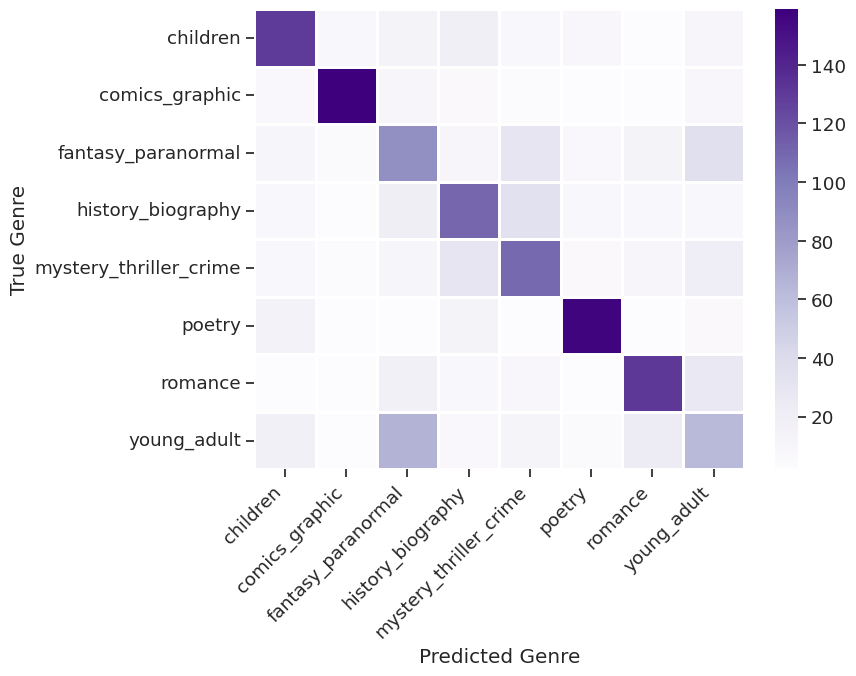

In [50]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Looks good! We can see that overall, our model is assigning the correct labels for each genre.

Now, let's remove the diagonal from the plot to highlight the misclassifications.

In [51]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

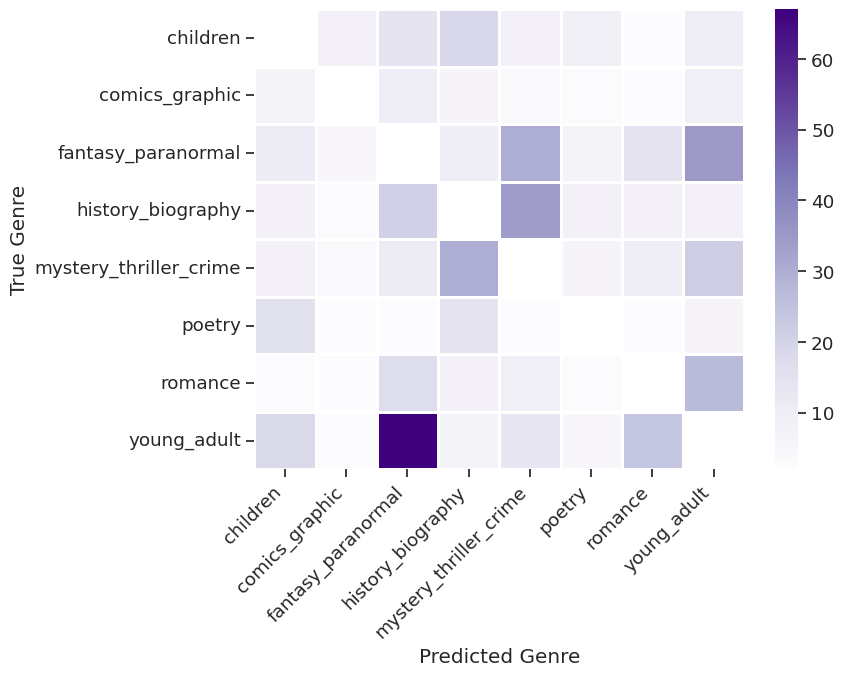

In [52]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There's much more you can do with your own dataset and labels! Classification can be used to apply a small set of labels across a big dataset; to explore misclassifications to better understand users; and much more! We hope you'll use this tutorial in all kinds of creative ways.

# **Task: Updating HF Model Card with Evaluation Results**

In [53]:
# Update HF model card with eval results
from huggingface_hub import ModelCard

eval_results = trainer.evaluate()

card_content = f"""---
license: apache-2.0
tags:
- text-classification
- distilbert
- goodreads
- genre-classification
metrics:
- accuracy
- f1
---

# DistilBERT Goodreads Genre Classification

## Model Description
Fine-tuned DistilBERT model for classifying book reviews into 8 genres.

## Training Hyperparameters
- Epochs: 3
- Batch Size: 16
- Learning Rate: 3e-5
- Optimizer: AdamW

## Evaluation Results
| Metric    | Score  |
|-----------|--------|
| Accuracy  | {eval_results['eval_accuracy']:.4f} |
| F1 Score  | {eval_results['eval_f1']:.4f} |
| Eval Loss | {eval_results['eval_loss']:.4f} |

## Links
- **W&B:** https://wandb.ai/g25ait2023-iit-jodhpur/mlops-assignment2
- **Kaggle:** https://www.kaggle.com/code/ahalderg25ait2023/mlops-assignment-kaggle
- **GitHub:** https://github.com/halderatreyee-hash/MLOPS-ASSIGNMENT2_Kaggle
"""

card = ModelCard(card_content)
card.push_to_hub("Atreyee-Halder/distilbert-goodreads-genres")
print(f"Model card updated! Accuracy: {eval_results['eval_accuracy']:.4f}, F1: {eval_results['eval_f1']:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1
1.736420,2.263319,3,0.591875,0.593486


Model card updated! Accuracy: 0.5919, F1: 0.5935


# **Task: Finish W&B Run**

In [54]:
# ===== End W&B run =====
wandb.finish()
print("All done! Check your W&B dashboard.")

wandb: updating run metadata


wandb: uploading output.log; uploading wandb-summary.json; uploading config.yaml


wandb: uploading wandb-summary.json; uploading config.yaml


wandb: 
wandb: Run history:
wandb:           eval/accuracy ▁▇████
wandb:                 eval/f1 ▁▇████
wandb:               eval/loss █▁▁▁▁▁
wandb:            eval/runtime █▄▆▃▆▁
wandb: eval/samples_per_second ▁▅▃▆▃█
wandb:   eval/steps_per_second ▁▅▃▆▃█
wandb:          final/accuracy ▁
wandb:                final/f1 ▁
wandb:              final/loss ▁
wandb:           test/accuracy ▁▁
wandb:                     +10 ...
wandb: 
wandb: Run summary:
wandb:           eval/accuracy 0.59188
wandb:                 eval/f1 0.59349
wandb:               eval/loss 2.26332
wandb:            eval/runtime 15.8633
wandb: eval/samples_per_second 100.862
wandb:   eval/steps_per_second 1.576
wandb:          final/accuracy 0.59188
wandb:                final/f1 0.59349
wandb:              final/loss 2.26332
wandb:       huggingface_model https://huggingface....
wandb:                     +16 ...
wandb: 


wandb: 🚀 View run distilbert-run-1 at: https://wandb.ai/g25ait2023-iit-jodhpur/mlops-assignment2/runs/0ln16vla
wandb: ⭐️ View project at: https://wandb.ai/g25ait2023-iit-jodhpur/mlops-assignment2
wandb: Synced 5 W&B file(s), 0 media file(s), 2 artifact file(s) and 0 other file(s)


wandb: Find logs at: ./wandb/run-20260526_031446-0ln16vla/logs


All done! Check your W&B dashboard.


In [55]:
import os
print("Files in working directory:")
for f in os.listdir('/kaggle/working/'):
    print(f" - {f}")

Files in working directory:
 - eval_report.json
 - genre_reviews_dict.pickle
 - results
 - wandb
 - __notebook__.ipynb
 - distilbert-reviews-genres


# **Task: Pushing Everything to GitHub**

In [56]:
from kaggle_secrets import UserSecretsClient
import os

secrets = UserSecretsClient()
GIT_TOKEN = secrets.get_secret('Kaggle-Push')

# Configure git
os.system('git config --global user.email "g25ait2023@iitj.ac.in"')
os.system('git config --global user.name "Atreyee Halder"')

0

In [ ]:
# Clone your repo
os.system('rm -rf MLOPS-ASSIGNMENT2_Kaggle')
os.system(f'git clone https://{GIT_TOKEN}@github.com/halderatreyee-hash/MLOPS-ASSIGNMENT2_Kaggle.git')

# Copy notebook and eval report into the repo folder
os.system('cp /kaggle/working/*.ipynb MLOPS-ASSIGNMENT2_Kaggle/')
os.system('cp /kaggle/working/eval_report.json MLOPS-ASSIGNMENT2_Kaggle/')

# Push to GitHub
os.chdir('MLOPS-ASSIGNMENT2_Kaggle')
os.system('git add .')
os.system('git commit -m "Add Kaggle notebook and eval report" --allow-empty')
os.system('git push')
os.chdir('/kaggle/working')
print("Pushed to GitHub!")

In [ ]:
# Generate complete README with static + dynamic content
readme = f"""# MLOps Assignment 2 — Hugging Face Fine-Tuning, Experiment Tracking & Model Deployment

**Course:** MLOps | PGD AI Program | IIT Jodhpur  
**Author:** Atreyee Halder (G25AIT2023)

---

## Project Description

This project demonstrates a complete MLOps pipeline for fine-tuning a **DistilBERT** model on the [UCSD Goodreads Book Graph](https://mengtingwan.github.io/data/goodreads.html#datasets) dataset to classify book reviews into **8 genres**. The workflow covers experiment tracking with Weights & Biases, model hosting on Hugging Face Hub, and reproducible training on Kaggle with GPU acceleration.

### Genre Labels

| # | Genre |
|---|-------|
| 1 | poetry |
| 2 | children |
| 3 | comics_graphic |
| 4 | fantasy_paranormal |
| 5 | history_biography |
| 6 | mystery_thriller_crime |
| 7 | romance |
| 8 | young_adult |

---

## Pipeline Overview

```
Data Ingestion → Baseline Model → Tokenization → Fine-Tuning → Evaluation → Deployment
     |                |                |              |              |            |
  UCSD Goodreads   TF-IDF +       DistilBERT     HuggingFace    W&B Logging   HF Hub +
  (8 genres)       LogReg          Tokenizer      Trainer        & Artifacts   GitHub
```

### Step-by-Step Workflow

1. **Data Collection** - Stream and sample 2,000 reviews per genre (16,000 total) from UCSD Goodreads hosted datasets.
2. **Train/Test Split** - 800 train + 200 test per genre → 6,400 training / 1,600 test samples.
3. **Baseline Model** - TF-IDF + Logistic Regression to establish a baseline performance benchmark.
4. **Tokenization** - Encode texts using `DistilBertTokenizerFast` with truncation and padding (max 512 tokens).
5. **Fine-Tuning** - Fine-tune `distilbert-base-cased` using HuggingFace `Trainer` with W&B integration.
6. **Evaluation** - Generate classification report, log metrics (accuracy, F1, loss) to W&B.
7. **Artifact Logging** - Save `eval_report.json` as a versioned W&B Artifact.
8. **Model Deployment** - Push fine-tuned model and tokenizer to Hugging Face Hub.
9. **Model Card** - Auto-update HF model card with evaluation results and hyperparameters.
10. **Version Control** - Push notebook, eval report, and README to GitHub.

----

## Model & Training Configuration

| Parameter | Value |
|-----------|-------|
| Base Model | `distilbert-base-cased` |
| Max Token Length | 512 |
| Epochs | 3 |
| Train Batch Size | 16 |
| Eval Batch Size | 32 |
| Learning Rate | 3e-5 |
| Warmup Steps | 100 |
| Weight Decay | 0.01 |
| Optimizer | AdamW |
| Logging Steps | 50 |
| Eval Strategy | Per Epoch |
| Platform | Kaggle (GPU T4 x2) |

---

## Results 

| Metric | Score |
|--------|-------|
| Accuracy | {eval_results['eval_accuracy']:.4f} |
| Weighted F1 | {eval_results['eval_f1']:.4f} |
| Eval Loss | {eval_results['eval_loss']:.4f} |

### Per-Genre Classification Report

| Genre | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| children | {report['children']['precision']:.2f} | {report['children']['recall']:.2f} | {report['children']['f1-score']:.2f} | {int(report['children']['support'])} |
| comics_graphic | {report['comics_graphic']['precision']:.2f} | {report['comics_graphic']['recall']:.2f} | {report['comics_graphic']['f1-score']:.2f} | {int(report['comics_graphic']['support'])} |
| fantasy_paranormal | {report['fantasy_paranormal']['precision']:.2f} | {report['fantasy_paranormal']['recall']:.2f} | {report['fantasy_paranormal']['f1-score']:.2f} | {int(report['fantasy_paranormal']['support'])} |
| history_biography | {report['history_biography']['precision']:.2f} | {report['history_biography']['recall']:.2f} | {report['history_biography']['f1-score']:.2f} | {int(report['history_biography']['support'])} |
| mystery_thriller_crime | {report['mystery_thriller_crime']['precision']:.2f} | {report['mystery_thriller_crime']['recall']:.2f} | {report['mystery_thriller_crime']['f1-score']:.2f} | {int(report['mystery_thriller_crime']['support'])} |
| poetry | {report['poetry']['precision']:.2f} | {report['poetry']['recall']:.2f} | {report['poetry']['f1-score']:.2f} | {int(report['poetry']['support'])} |
| romance | {report['romance']['precision']:.2f} | {report['romance']['recall']:.2f} | {report['romance']['f1-score']:.2f} | {int(report['romance']['support'])} |
| young_adult | {report['young_adult']['precision']:.2f} | {report['young_adult']['recall']:.2f} | {report['young_adult']['f1-score']:.2f} | {int(report['young_adult']['support'])} |

### Key Observations

- **Best performing genres:** `comics_graphic` and `poetry` - these have distinctive review language.
- **Most confused genres:** `young_adult` and `fantasy_paranormal` - frequently misclassified as `mystery_thriller_crime` due to overlapping vocabulary.
- **Overall:** {eval_results['eval_accuracy']:.1%} accuracy across 8 classes is well above the ~12.5% random baseline.

---

## MLOps Tools & Integration

| Tool | Purpose |
|------|---------|
| **Weights & Biases** | Experiment tracking, metric logging, artifact versioning |
| **Hugging Face Hub** | Model hosting, model card, inference API |
| **Kaggle** | Training platform with GPU T4 x2 acceleration |
| **GitHub** | Version control for notebook, eval report, and README |

### W&B Tracking Details

- **Project:** `mlops-assignment2`
- **Run Name:** `distilbert-run-1`
- **Logged Metrics:** `eval/loss`, `eval/accuracy`, `eval/f1`, `final/loss`, `final/accuracy`, `final/f1`, `train/loss`
- **Artifacts:** `eval-report` (classification report JSON)
- **System Metrics:** GPU utilization, memory, CPU, temperature

---

## Repository Structure

```
MLOPS-ASSIGNMENT2_Kaggle/
├── README.md                         # Project documentation (auto-generated + static)
├── mlops-assignment-kaggle.ipynb     # Full training notebook (Kaggle)
├── eval_report.json                  # Per-genre evaluation metrics (W&B artifact)
└── requirements.txt                  # Python dependencies
```

---

## Setup Instructions

1. Import the notebook into **Kaggle**.
2. Enable GPU: **Settings → Accelerator → GPU T4 x2**
3. Enable Internet: **Settings → Internet → ON**
4. Add Kaggle Secrets:
   - `WANDB_API_KEY` - from [wandb.ai/authorize](https://wandb.ai/authorize)
   - `HF_TOKEN` - from [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens)
   - `Kaggle-Push` - GitHub personal access token for repo push
5. Click **Run All**.

---

## Inference Example

```python
from transformers import pipeline

classifier = pipeline(
    "text-classification",
    model="Atreyee-Halder/distilbert-goodreads-genres",
    top_k=None
)

result = classifier("A thrilling mystery set in Victorian London with unexpected twists.")
print(result)
```

---

## Links

- **GitHub:** [halderatreyee-hash/MLOPS-ASSIGNMENT2_Kaggle](https://github.com/halderatreyee-hash/MLOPS-ASSIGNMENT2_Kaggle)
- **Kaggle:** [mlops-assignment-kaggle](https://www.kaggle.com/code/ahalderg25ait2023/mlops-assignment-kaggle)
- **Hugging Face:** [Atreyee-Halder/distilbert-goodreads-genres](https://huggingface.co/Atreyee-Halder/distilbert-goodreads-genres)
- **W&B Dashboard:** [mlops-assignment2](https://wandb.ai/g25ait2023-iit-jodhpur/mlops-assignment2)
"""

with open("MLOPS-ASSIGNMENT2_Kaggle/README.md", "w") as f:
    f.write(readme)
print(f"README created! Accuracy: {eval_results['eval_accuracy']:.4f}, F1: {eval_results['eval_f1']:.4f}")

# Create requirements.txt
req = """transformers>=4.40.0
torch>=2.0.0
scikit-learn>=1.3.0
pandas>=2.0.0
numpy>=1.24.0
wandb>=0.16.0
huggingface_hub>=0.20.0
requests>=2.31.0
matplotlib>=3.7.0
seaborn>=0.12.0
"""

with open("MLOPS-ASSIGNMENT2_Kaggle/requirements.txt", "w") as f:
    f.write(req)
print("requirements.txt created")

# Push to GitHub
os.chdir('MLOPS-ASSIGNMENT2_Kaggle')
os.system('git add .')
os.system('git commit -m "Update README with full results and requirements.txt"')
os.system('git push --force')
os.chdir('/kaggle/working')
print("Pushed to GitHub!")

# **Model Inference Test**

In [ ]:
from transformers import pipeline

# Download your model from HF and create a classifier
classifier = pipeline("text-classification", 
                      model="Atreyee-Halder/distilbert-goodreads-genres", 
                      top_k=None)

# Label mapping (from your notebook's id2label dictionary)
label_map = {
    "LABEL_0": "poetry",
    "LABEL_1": "fantasy_paranormal",
    "LABEL_2": "comics_graphic",
    "LABEL_3": "mystery_thriller_crime",
    "LABEL_4": "young_adult",
    "LABEL_5": "history_biography",
    "LABEL_6": "romance",
    "LABEL_7": "children",
}

reviews = [
    "Beautiful poems with vivid imagery and deep emotions",
    "A thrilling murder mystery with a shocking twist ending",
    "My kids loved the colorful pictures and fun story",
    "An epic fantasy quest with dragons and magic spells",
    "A passionate love story set in Paris",
]

for review in reviews:
    result = classifier(review)
    top = result[0][0]
    genre = label_map[top['label']]
    print(f"\nReview: {review}")
    print(f"Predicted: {genre} ({top['score']*100:.1f}%)")